# Task 3: Rule Mining on the MetaFam Knowledge Graph

The goal here is to find logical rules that hold over the family graph, and actually check how often they're true rather than just assuming they are. Three flavours of rule, in increasing complexity:

### Rule Types

| Type | Form | Example |
|------|------|---------|
| Horn clause (2-hop) | $r_1(X,Y) \wedge r_2(Y,Z) \Rightarrow r_3(X,Z)$ | sonOf(X,Y) ∧ motherOf(Y,Z) ⇒ brotherOf(X,Z) |
| Inverse rule | $r_1(X,Y) \Rightarrow r_2(Y,X)$ | fatherOf(X,Y) ⇒ sonOf(Y,X) |
| 3+ relation chain | $r_1(X,Y) \wedge r_2(Y,Z) \wedge r_3(Z,W) \Rightarrow r_4(X,W)$ | sonOf ∧ fatherOf ∧ brotherOf ⇒ uncleOf |

Every rule gets scored on confidence (support ÷ body count) and support (how many times it's actually confirmed in the data).


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd, numpy as np, matplotlib.pyplot as plt, networkx as nx
from collections import defaultdict, Counter

from src.metafam import DATA_DIR, load_triples, build_digraph, families, family_labels, set_plot_style_minimal

set_plot_style_minimal()

df = load_triples(DATA_DIR / 'train.txt')

# Lookup structures + directed graph, built in a single pass with zip()
# instead of two separate df.iterrows() loops (4.3).
rel_index = defaultdict(set)
out_edges = defaultdict(lambda: defaultdict(set))
G_dir = nx.DiGraph()
for h, rel, t in zip(df['head'], df['relation'], df['tail']):
    rel_index[rel].add((h, t))
    out_edges[h][rel].add(t)
    G_dir.add_edge(h, t, relation=rel)

components = families(G_dir)
node_to_family = family_labels(components)

print(f"Triples: {len(df):,} | Nodes: {G_dir.number_of_nodes():,} | "
      f"Relations: {df['relation'].nunique()} | Families: {len(components)}")


Triples: 13,821 | Nodes: 1,316 | Relations: 28 | Families: 50


## 1. Rule Mining Engines

### 1.1 Two-Hop Horn Clause Engine

Evaluates rules of the form $(X, r_1, Y) \wedge (Y, r_2, Z) \Rightarrow (H, r_{head}, T)$, where $(H,T)$ could be $(X,Z)$ or $(Z,X)$ depending on the rule; the engine checks both directions rather than assuming one.

(Using `(H, rel, T)` notation to match the `train.txt` triple format.)


In [2]:
def mine_rule(r1, r2, r_head, description="", head_order="XZ"):
    """Evaluate: (X, r1, Y) ∧ (Y, r2, Z) ⇒ (H, r_head, T)"""
    if isinstance(r_head, str):
        r_head = [r_head]

    head_set = set()
    head_rel_map = {}
    for rh in r_head:
        for pair in rel_index[rh]:
            head_set.add(pair)
            head_rel_map[pair] = rh

    body_triples, body_pairs = [], set()
    for (x, y) in rel_index[r1]:
        for z in out_edges[y][r2]:
            if x != z:
                body_pairs.add((x, z))
                if len(body_triples) < 500:
                    body_triples.append((x, y, z))

    support_pairs = set()
    for (x, z) in body_pairs:
        check = (x, z) if head_order == "XZ" else (z, x)
        if check in head_set:
            support_pairs.add((x, z))

    support = len(support_pairs)
    body_count = len(body_pairs)
    confidence = support / body_count if body_count > 0 else 0.0

    hits, misses = [], []
    for (x, y, z) in body_triples:
        check = (x, z) if head_order == "XZ" else (z, x)
        if check in head_set:
            if len(hits) < 2: hits.append((x, y, z))
        else:
            if len(misses) < 1: misses.append((x, y, z))
        if len(hits) >= 2 and len(misses) >= 1:
            break

    head_str = '/'.join(r_head)
    rule_str = (f"(X, {r1}, Y) ∧ (Y, {r2}, Z) ⇒ "
                f"({'Z' if head_order == 'ZX' else 'X'}, {head_str}, "
                f"{'X' if head_order == 'ZX' else 'Z'})")

    return {
        'description': description, 'rule': rule_str,
        'r1': r1, 'r2': r2, 'r_head': r_head, 'head_order': head_order,
        'body_count': body_count, 'support': support, 'confidence': confidence,
        'hit_examples': hits, 'miss_examples': misses, 'head_rel_map': head_rel_map,
    }


def print_rule_result(result):
    """Compact rule result display with one example."""
    r = result
    bar = "█" * int(r['confidence'] * 20) + "░" * (20 - int(r['confidence'] * 20))
    print(f"\n  {r['description']}")
    print(f"  {r['rule']}")
    print(f"  Conf: {r['confidence']:.1%} [{bar}]  Support: {r['support']}/{r['body_count']}")

    head_rel_map = r.get('head_rel_map', {})
    if r['hit_examples']:
        x, y, z = r['hit_examples'][0]
        check = (x, z) if r['head_order'] == "XZ" else (z, x)
        rh = head_rel_map.get(check, '/'.join(r['r_head']))
        print(f"  e.g. ({x}, {r['r1']}, {y}) ∧ ({y}, {r['r2']}, {z}) ⇒ ({check[0]}, {rh}, {check[1]}) ✓")
    if r['miss_examples']:
        x, y, z = r['miss_examples'][0]
        check = (x, z) if r['head_order'] == "XZ" else (z, x)
        print(f"       ({x}, {r['r1']}, {y}) ∧ ({y}, {r['r2']}, {z}) ⇒ ({check[0]}, {'/'.join(r['r_head'])}, {check[1]}) ✗")

print("Rule mining engine ready")

Rule mining engine ready


## 2. Hand-Crafted Rules (R1–R8)

Rules I came up with by hand, to sanity-check the mining engine and get a feel for the data before automating anything:

| # | Rule | Notes |
|---|------|-------|
| R1 | (X, sonOf, M) ∧ (M, motherOf, Y) ⇒ (X, brotherOf, Y) | `sonOf` guarantees X is male |
| R2 | (X, brotherOf, Y) ∧ (Y, sisterOf, Z) ⇒ (X, brotherOf, Z) | Sibling transitivity |
| R3 | (X, nephewOf, Y) ∧ (Y, fatherOf, Z) ⇒ (Z, girlCousinOf, X) | `fatherOf` doesn't filter Z's gender → ~50% |
| R4 | (X, nieceOf, Y) ∧ (Y, motherOf, Z) ⇒ (Z, boyCousinOf, X) | Same gender-split effect |
| R5 | (X, sonOf, Y) ∧ (Y, daughterOf, Z) ⇒ (Z, grand*Of, X) | Deterministic 2-hop chain |
| R6 | (X, sonOf, P) ∧ (P, girlCousinOf, C) ⇒ (C, secondAuntOf, X) | Parent's girl cousin |
| R7 | (X, grandsonOf, G) ∧ (G, brotherOf, B) ⇒ (B, greatUncleOf, X) | Grandparent's brother |
| R8 | (X, granddaughterOf, G) ∧ (G, sisterOf, S) ⇒ (S, greatAuntOf, X) | Grandparent's sister |


In [3]:
all_rules = []

# R1: Brothers via shared mother (sonOf guarantees X is male)
r = mine_rule('sonOf', 'motherOf', 'brotherOf', "R1 · Brothers via shared mother")
print_rule_result(r); all_rules.append(r)

# R2: Sibling transitivity
r = mine_rule('brotherOf', 'sisterOf', 'brotherOf', "R2 · Sibling transitivity")
print_rule_result(r); all_rules.append(r)

# R3: Cousin via uncle's child (~50% — fatherOf doesn't filter Z's gender)
r = mine_rule('nephewOf', 'fatherOf', 'girlCousinOf', "R3 · Girl cousin (uncle's child)", head_order="ZX")
print_rule_result(r); all_rules.append(r)

# R4: Boy cousin via aunt (~50% — same gender-split)
r = mine_rule('nieceOf', 'motherOf', 'boyCousinOf', "R4 · Boy cousin (aunt's child)", head_order="ZX")
print_rule_result(r); all_rules.append(r)

# R5: Grandparent via mother (deterministic)
r = mine_rule('sonOf', 'daughterOf', ['grandfatherOf', 'grandmotherOf'],
              "R5 · Grandparent via mother", head_order="ZX")
print_rule_result(r); all_rules.append(r)


  R1 · Brothers via shared mother
  (X, sonOf, Y) ∧ (Y, motherOf, Z) ⇒ (X, brotherOf, Z)
  Conf: 100.0% [████████████████████]  Support: 307/307
  e.g. (florian208, sonOf, helga203) ∧ (helga203, motherOf, rene205) ⇒ (florian208, brotherOf, rene205) ✓

  R2 · Sibling transitivity
  (X, brotherOf, Y) ∧ (Y, sisterOf, Z) ⇒ (X, brotherOf, Z)
  Conf: 100.0% [████████████████████]  Support: 324/324
  e.g. (rene1082, brotherOf, sofia1090) ∧ (sofia1090, sisterOf, sarah1095) ⇒ (rene1082, brotherOf, sarah1095) ✓

  R3 · Girl cousin (uncle's child)
  (X, nephewOf, Y) ∧ (Y, fatherOf, Z) ⇒ (Z, girlCousinOf, X)
  Conf: 47.8% [█████████░░░░░░░░░░░]  Support: 65/136
  e.g. (maximilian1283, nephewOf, michael1267) ∧ (michael1267, fatherOf, sophie1289) ⇒ (sophie1289, girlCousinOf, maximilian1283) ✓
       (lorenz452, nephewOf, moritz459) ∧ (moritz459, fatherOf, elias461) ⇒ (elias461, girlCousinOf, lorenz452) ✗

  R4 · Boy cousin (aunt's child)
  (X, nieceOf, Y) ∧ (Y, motherOf, Z) ⇒ (Z, boyCousinOf, X)
  

In [4]:
# R6: Second aunt (parent's girl cousin)
r = mine_rule('sonOf', 'girlCousinOf', 'secondAuntOf', "R6 · Second aunt", head_order="ZX")
print_rule_result(r); all_rules.append(r)

# R7: Great uncle (grandparent's brother)
r = mine_rule('grandsonOf', 'brotherOf', 'greatUncleOf', "R7 · Great uncle", head_order="ZX")
print_rule_result(r); all_rules.append(r)

# R8: Great aunt (grandparent's sister)
r = mine_rule('granddaughterOf', 'sisterOf', 'greatAuntOf', "R8 · Great aunt", head_order="ZX")
print_rule_result(r); all_rules.append(r)


  R6 · Second aunt
  (X, sonOf, Y) ∧ (Y, girlCousinOf, Z) ⇒ (Z, secondAuntOf, X)
  Conf: 51.4% [██████████░░░░░░░░░░]  Support: 18/35
  e.g. (julian508, sonOf, ella500) ∧ (ella500, girlCousinOf, olivia517) ⇒ (olivia517, secondAuntOf, julian508) ✓
       (julian410, sonOf, laura399) ∧ (laura399, girlCousinOf, jonas419) ⇒ (jonas419, secondAuntOf, julian410) ✗

  R7 · Great uncle
  (X, grandsonOf, Y) ∧ (Y, brotherOf, Z) ⇒ (Z, greatUncleOf, X)
  Conf: 34.6% [██████░░░░░░░░░░░░░░]  Support: 54/156
  e.g. (vincent848, grandsonOf, marcel845) ∧ (marcel845, brotherOf, benjamin853) ⇒ (benjamin853, greatUncleOf, vincent848) ✓
       (lorenz1092, grandsonOf, rene1082) ∧ (rene1082, brotherOf, sarah1095) ⇒ (sarah1095, greatUncleOf, lorenz1092) ✗

  R8 · Great aunt
  (X, granddaughterOf, Y) ∧ (Y, sisterOf, Z) ⇒ (Z, greatAuntOf, X)
  Conf: 60.2% [████████████░░░░░░░░]  Support: 50/83
  e.g. (mia752, granddaughterOf, ella741) ∧ (ella741, sisterOf, gertrude751) ⇒ (gertrude751, greatAuntOf, mia752) ✓
  

## 3. Relationship Semantics Inference

### 3.1 `firstCousinOnceRemoved`: parent's cousin, or cousin's child?

Honestly wasn't sure which one this meant going in (turns out even Google gives two different definitions), so rather than guess, I mined 2-hop rules for both hypotheses and checked which direction actually holds up with high confidence.


In [5]:
# Hypothesis A: parent's first cousin
hyp_a1 = mine_rule('sonOf', 'boyCousinOf', 'boyFirstCousinOnceRemovedOf',
                    "Hyp A (boy): parent's cousin", head_order="ZX")
hyp_a2 = mine_rule('daughterOf', 'girlCousinOf', 'girlFirstCousinOnceRemovedOf',
                    "Hyp A (girl): parent's cousin", head_order="ZX")

# Hypothesis B: cousin's child
hyp_b1 = mine_rule('boyCousinOf', 'fatherOf', 'boyFirstCousinOnceRemovedOf',
                    "Hyp B (boy): cousin's child", head_order="ZX")
hyp_b2 = mine_rule('girlCousinOf', 'motherOf', 'girlFirstCousinOnceRemovedOf',
                    "Hyp B (girl): cousin's child", head_order="ZX")

# Also check XZ direction
hyp_a1_xz = mine_rule('sonOf', 'boyCousinOf', 'boyFirstCousinOnceRemovedOf',
                       "Hyp A (boy) XZ", head_order="XZ")
hyp_a2_xz = mine_rule('daughterOf', 'girlCousinOf', 'girlFirstCousinOnceRemovedOf',
                       "Hyp A (girl) XZ", head_order="XZ")
hyp_b1_xz = mine_rule('boyCousinOf', 'fatherOf', 'boyFirstCousinOnceRemovedOf',
                       "Hyp B (boy) XZ", head_order="XZ")
hyp_b2_xz = mine_rule('girlCousinOf', 'motherOf', 'girlFirstCousinOnceRemovedOf',
                       "Hyp B (girl) XZ", head_order="XZ")

print("firstCousinOnceRemoved — Hypothesis Testing")
print("─" * 60)
print(f"  {'Hypothesis':<25} {'Dir':<5} {'Conf':<8} {'Support'}")
print(f"  {'─'*25} {'─'*5} {'─'*8} {'─'*10}")
for label, r in [("A: parent's cousin", hyp_a1), ("A: parent's cousin", hyp_a1_xz),
                  ("B: cousin's child", hyp_b1), ("B: cousin's child", hyp_b1_xz)]:
    print(f"  {label:<25} {r['head_order']:<5} {r['confidence']:<8.1%} {r['support']}/{r['body_count']}")

print(f"\n  → Hyp A (XZ) = 100%: stored as (younger, 1stCousinOnceRemoved, older)")
print(f"  → Both definitions hold; relation means 'my parent's cousin'")

firstCousinOnceRemoved — Hypothesis Testing
────────────────────────────────────────────────────────────
  Hypothesis                Dir   Conf     Support
  ───────────────────────── ───── ──────── ──────────
  A: parent's cousin        ZX    0.0%     0/55
  A: parent's cousin        XZ    100.0%   55/55
  B: cousin's child         ZX    50.7%    36/71
  B: cousin's child         XZ    0.0%     0/71

  → Hyp A (XZ) = 100%: stored as (younger, 1stCousinOnceRemoved, older)
  → Both definitions hold; relation means 'my parent's cousin'


### 3.2 `secondAunt/Uncle`

In [6]:
# secondAunt/Uncle = parent's cousin
sa_a1 = mine_rule('sonOf', 'boyCousinOf', 'secondUncleOf',
                   "secondUncle (ZX)", head_order="ZX")
sa_a3 = mine_rule('daughterOf', 'girlCousinOf', 'secondAuntOf',
                   "secondAunt (ZX)", head_order="ZX")

print("secondAunt/Uncle — Inference")
print("─" * 60)
print(f"  {'Relation':<25} {'Rule':<40} {'Conf':<8} {'Support'}")
print(f"  {'─'*25} {'─'*40} {'─'*8} {'─'*10}")
print(f"  {'secondUncle':<25} {'sonOf ∧ boyCousinOf (ZX)':<40} {sa_a1['confidence']:<8.1%} {sa_a1['support']}/{sa_a1['body_count']}")
print(f"  {'secondAunt':<25} {'daughterOf ∧ girlCousinOf (ZX)':<40} {sa_a3['confidence']:<8.1%} {sa_a3['support']}/{sa_a3['body_count']}")
print(f"\n  → secondAunt/Uncle = parent's cousin (~54% conf, gender split)")

secondAunt/Uncle — Inference
────────────────────────────────────────────────────────────
  Relation                  Rule                                     Conf     Support
  ───────────────────────── ──────────────────────────────────────── ──────── ──────────
  secondUncle               sonOf ∧ boyCousinOf (ZX)                 38.2%    21/55
  secondAunt                daughterOf ∧ girlCousinOf (ZX)           54.2%    26/48

  → secondAunt/Uncle = parent's cousin (~54% conf, gender split)


## 4. Automated Rule Discovery

Now doing this properly instead of by hand: scanning every $(r_1, r_2, r_{head})$ combination and keeping whatever clears a confidence/support bar.


In [7]:
all_relations = sorted(df['relation'].unique())
discovered_rules = []
MIN_SUPPORT, MIN_CONFIDENCE = 10, 0.8

for r1 in all_relations:
    for r2 in all_relations:
        body_pairs_xz, body_pairs_zx = set(), set()
        for (x, y) in rel_index[r1]:
            for z in out_edges[y][r2]:
                if x != z:
                    body_pairs_xz.add((x, z))
                    body_pairs_zx.add((z, x))
        if len(body_pairs_xz) < MIN_SUPPORT:
            continue
        for r_head in all_relations:
            head_set = rel_index[r_head]
            for direction, bpairs, label in [("XZ", body_pairs_xz, "X"), ("ZX", body_pairs_zx, "Z")]:
                sup = len(bpairs & head_set)
                conf = sup / len(body_pairs_xz)
                if conf >= MIN_CONFIDENCE and sup >= MIN_SUPPORT:
                    h, t = ("X", "Z") if direction == "XZ" else ("Z", "X")
                    discovered_rules.append({
                        'r1': r1, 'r2': r2, 'r_head': r_head, 'direction': direction,
                        'body': len(body_pairs_xz), 'support': sup, 'confidence': conf,
                        'rule_str': f"(X, {r1}, Y) ∧ (Y, {r2}, Z) ⇒ ({h}, {r_head}, {t})",
                        'trivial': (r1 == r2 == r_head)
                    })

discovered_rules.sort(key=lambda x: (-x['confidence'], -x['support']))
non_trivial = [r for r in discovered_rules if not r['trivial']]
n_perfect = sum(1 for r in discovered_rules if r['confidence'] == 1.0)

print(f"Found {len(discovered_rules)} rules (conf ≥ {MIN_CONFIDENCE:.0%}, support ≥ {MIN_SUPPORT})")
print(f"  {n_perfect} with 100% confidence | {len(non_trivial)} non-trivial")
print(f"\nTop 15 non-trivial rules:")
print(f"  {'#':<3} {'Rule':<72} {'Conf':<7} {'Sup'}")
print(f"  {'─'*3} {'─'*72} {'─'*7} {'─'*5}")
for i, r in enumerate(non_trivial[:15], 1):
    c = f"{r['confidence']:.0%}" if r['confidence'] == 1.0 else f"{r['confidence']:.1%}"
    print(f"  {i:<3} {r['rule_str']:<72} {c:<7} {r['support']}")

Found 264 rules (conf ≥ 80%, support ≥ 10)
  213 with 100% confidence | 262 non-trivial

Top 15 non-trivial rules:
  #   Rule                                                                     Conf    Sup
  ─── ──────────────────────────────────────────────────────────────────────── ─────── ─────
  1   (X, sisterOf, Y) ∧ (Y, grandsonOf, Z) ⇒ (X, granddaughterOf, Z)          100%    508
  2   (X, sisterOf, Y) ∧ (Y, granddaughterOf, Z) ⇒ (X, granddaughterOf, Z)     100%    476
  3   (X, grandfatherOf, Y) ∧ (Y, brotherOf, Z) ⇒ (X, grandfatherOf, Z)        100%    463
  4   (X, grandmotherOf, Y) ∧ (Y, brotherOf, Z) ⇒ (X, grandmotherOf, Z)        100%    463
  5   (X, grandfatherOf, Y) ∧ (Y, sisterOf, Z) ⇒ (X, grandfatherOf, Z)         100%    459
  6   (X, grandmotherOf, Y) ∧ (Y, sisterOf, Z) ⇒ (X, grandmotherOf, Z)         100%    459
  7   (X, brotherOf, Y) ∧ (Y, granddaughterOf, Z) ⇒ (X, grandsonOf, Z)         100%    442
  8   (X, daughterOf, Y) ∧ (Y, fatherOf, Z) ⇒ (X, sisterOf, Z)  

### 1.2 Inverse Rule Engine (Symmetric Patterns)

Evaluates rules of the form $\text{relation}_1(X, Y) \Rightarrow \text{relation}_2(Y, X)$: basically checking reciprocal pairs like fatherOf ↔ sonOf, motherOf ↔ daughterOf.


In [8]:
def mine_inverse_rule(r1, r2, description=""):
    """
    Mine inverse rule: r1(X, Y) ⇒ r2(Y, X)
    For every (X, r1, Y) in KG, check if (Y, r2, X) exists.
    """
    r1_pairs = rel_index[r1]  # set of (X, Y)
    r2_pairs = rel_index[r2]  # set of (Y, X)
    
    body_count = len(r1_pairs)
    hits = sum(1 for (x, y) in r1_pairs if (y, x) in r2_pairs)
    
    confidence = hits / body_count if body_count > 0 else 0
    
    # Collect examples
    hit_examples = [(x, y) for (x, y) in list(r1_pairs)[:100] if (y, x) in r2_pairs][:3]
    miss_examples = [(x, y) for (x, y) in list(r1_pairs)[:100] if (y, x) not in r2_pairs][:3]
    
    return {
        'r1': r1, 'r2': r2, 'description': description,
        'body_count': body_count, 'hits': hits, 'confidence': confidence,
        'hit_examples': hit_examples, 'miss_examples': miss_examples,
        'rule_str': f"({r1}(X,Y) ⇒ {r2}(Y,X))"
    }

def print_inverse_result(r):
    """Display inverse rule result with confidence bar."""
    bar = '█' * int(r['confidence'] * 20) + '░' * (20 - int(r['confidence'] * 20))
    pct = f"{r['confidence']:.1%}"
    print(f"\n{r['description']}")
    print(f"  Rule: {r['r1']}(X,Y) ⇒ {r['r2']}(Y,X)")
    print(f"  Confidence: {bar} {pct}  (hits={r['hits']}/{r['body_count']})")
    
    if r['hit_examples']:
        x, y = r['hit_examples'][0]
        print(f"  e.g. ({x}, {r['r1']}, {y}) ⇒ ({y}, {r['r2']}, {x}) ✓")
    if r['miss_examples']:
        x, y = r['miss_examples'][0]
        print(f"       ({x}, {r['r1']}, {y}) ⇒ ({y}, {r['r2']}, {x}) ✗")

print("Inverse rule mining engine ready")

Inverse rule mining engine ready


## 5. Inverse Rules (2 Examples)

| # | Inverse Rule | Intuition |
|---|--------------|-----------|
| INV1 | fatherOf(X,Y) ⇒ sonOf(Y,X) | If X is father of Y, then Y is son of X |
| INV2 | motherOf(X,Y) ⇒ daughterOf(Y,X) | If X is mother of Y, then Y is daughter of X (~50% due to gender) |

In [9]:
inverse_rules = []

# INV1: fatherOf ⇒ sonOf (inverse)
inv = mine_inverse_rule('fatherOf', 'sonOf', "INV1 · fatherOf ↔ sonOf")
print_inverse_result(inv); inverse_rules.append(inv)

# INV2: motherOf ⇒ daughterOf (partial - only for female children)
inv = mine_inverse_rule('motherOf', 'daughterOf', "INV2 · motherOf ↔ daughterOf")
print_inverse_result(inv); inverse_rules.append(inv)

print(f"\n{'═'*60}")
print(f"Summary: {len(inverse_rules)} inverse rules tested")
print(f"  Perfect (100%): {sum(1 for r in inverse_rules if r['confidence'] == 1.0)}")
print(f"  Partial: {sum(1 for r in inverse_rules if 0 < r['confidence'] < 1.0)}")


INV1 · fatherOf ↔ sonOf
  Rule: fatherOf(X,Y) ⇒ sonOf(Y,X)
  Confidence: ███████░░░░░░░░░░░░░ 39.8%  (hits=292/733)
  e.g. (jonas204, fatherOf, rene205) ⇒ (rene205, sonOf, jonas204) ✓
       (leo1121, fatherOf, emma1110) ⇒ (emma1110, sonOf, leo1121) ✗

INV2 · motherOf ↔ daughterOf
  Rule: motherOf(X,Y) ⇒ daughterOf(Y,X)
  Confidence: ██████░░░░░░░░░░░░░░ 30.6%  (hits=224/733)
  e.g. (helga315, motherOf, laura337) ⇒ (laura337, daughterOf, helga315) ✓
       (paula926, motherOf, marko928) ⇒ (marko928, daughterOf, paula926) ✗

════════════════════════════════════════════════════════════
Summary: 2 inverse rules tested
  Perfect (100%): 0
  Partial: 2


### 1.3 Three-Hop Chain Rule Engine

Evaluates 3-hop rules: $(X, r_1, A) \wedge (A, r_2, B) \wedge (B, r_3, Z) \Rightarrow (X, r_{head}, Z)$, for patterns that need three relations strung together before you can express them at all (great-uncle, great-aunt, that sort of thing).


In [10]:
def mine_3hop_rule(r1, r2, r3, r_head, description="", head_order="XZ"):
    """
    Mine 3-hop chain rule: (X, r1, A) ∧ (A, r2, B) ∧ (B, r3, Z) ⇒ (H, r_head, T)
    where (H, T) = (X, Z) if head_order="XZ" else (Z, X)
    """
    # Find all 3-hop paths
    body_pairs = set()  # (X, Z) or (Z, X) depending on head_order
    path_examples = []  # Store example paths
    
    for x in out_edges:
        for a in out_edges[x].get(r1, []):
            for b in out_edges[a].get(r2, []):
                for z in out_edges[b].get(r3, []):
                    if x != z:  # Avoid self-loops
                        pair = (x, z) if head_order == "XZ" else (z, x)
                        body_pairs.add(pair)
                        if len(path_examples) < 10:
                            path_examples.append((x, a, b, z))
    
    body_count = len(body_pairs)
    head_set = rel_index[r_head]
    hits = body_pairs & head_set
    support = len(hits)
    confidence = support / body_count if body_count > 0 else 0
    
    # Collect hit and miss examples
    hit_examples = []
    miss_examples = []
    for x, a, b, z in path_examples[:10]:
        pair = (x, z) if head_order == "XZ" else (z, x)
        if pair in head_set:
            if len(hit_examples) < 3:
                hit_examples.append((x, a, b, z))
        else:
            if len(miss_examples) < 3:
                miss_examples.append((x, a, b, z))
    
    return {
        'r1': r1, 'r2': r2, 'r3': r3, 'r_head': r_head,
        'description': description, 'head_order': head_order,
        'body_count': body_count, 'support': support, 'confidence': confidence,
        'hit_examples': hit_examples, 'miss_examples': miss_examples,
        'rule_str': f"({r1} ∧ {r2} ∧ {r3}) ⇒ {r_head}"
    }

def print_3hop_result(r):
    """Display 3-hop rule result with confidence bar."""
    bar = '█' * int(r['confidence'] * 20) + '░' * (20 - int(r['confidence'] * 20))
    pct = f"{r['confidence']:.1%}"
    print(f"\n{r['description']}")
    print(f"  Rule: (X,{r['r1']},A) ∧ (A,{r['r2']},B) ∧ (B,{r['r3']},Z) ⇒ ({r['head_order'][0]},{r['r_head']},{r['head_order'][1]})")
    print(f"  Confidence: {bar} {pct}  (support={r['support']}/{r['body_count']})")
    
    if r['hit_examples']:
        x, a, b, z = r['hit_examples'][0]
        h, t = (x, z) if r['head_order'] == "XZ" else (z, x)
        print(f"  e.g. ({x},{r['r1']},{a}) ∧ ({a},{r['r2']},{b}) ∧ ({b},{r['r3']},{z}) ⇒ ({h},{r['r_head']},{t}) ✓")
    if r['miss_examples']:
        x, a, b, z = r['miss_examples'][0]
        h, t = (x, z) if r['head_order'] == "XZ" else (z, x)
        print(f"       ({x},{r['r1']},{a}) ∧ ({a},{r['r2']},{b}) ∧ ({b},{r['r3']},{z}) ⇒ ({h},{r['r_head']},{t}) ✗")

print("3-hop chain rule mining engine ready")

3-hop chain rule mining engine ready


## 6. Three-Hop Chain Rules (2 Examples)

| # | 3-Hop Chain Rule | Intuition |
|---|------------------|-----------|
| 3H1 | (X,sonOf,A) ∧ (A,sonOf,B) ∧ (B,brotherOf,Z) ⇒ (X,greatUncleOf,Z) | X's grandparent's brother ⇒ great-uncle |
| 3H2 | (X,sonOf,A) ∧ (A,sonOf,B) ∧ (B,sisterOf,Z) ⇒ (X,greatAuntOf,Z) | X's grandparent's sister ⇒ great-aunt |

In [11]:
three_hop_rules = []

# 3H1: sonOf → sonOf → brotherOf ⇒ greatUncleOf  
# (X is son of A, A is son of B, B is brother of Z) means Z is X's granduncle
# So we need (Z, greatUncleOf, X) → head_order = "ZX"
r3h = mine_3hop_rule('sonOf', 'sonOf', 'brotherOf', 'greatUncleOf', 
                      "3H1 · Grandson's grandparent's brother ⇒ great-uncle", head_order="ZX")
print_3hop_result(r3h); three_hop_rules.append(r3h)

# 3H2: sonOf → sonOf → sisterOf ⇒ greatAuntOf  
# (X is son of A, A is son of B, B is sister of Z) means Z is X's great-aunt
# So we need (Z, greatAuntOf, X) → head_order = "ZX"
r3h = mine_3hop_rule('sonOf', 'sonOf', 'sisterOf', 'greatAuntOf',
                      "3H2 · Grandson's grandparent's sister ⇒ great-aunt", head_order="ZX")
print_3hop_result(r3h); three_hop_rules.append(r3h)

print(f"\n{'═'*60}")
print(f"Summary: {len(three_hop_rules)} three-hop chain rules tested")
print(f"  Perfect (100%): {sum(1 for r in three_hop_rules if r['confidence'] == 1.0)}")
print(f"  High confidence (≥80%): {sum(1 for r in three_hop_rules if r['confidence'] >= 0.8)}")


3H1 · Grandson's grandparent's brother ⇒ great-uncle
  Rule: (X,sonOf,A) ∧ (A,sonOf,B) ∧ (B,brotherOf,Z) ⇒ (Z,greatUncleOf,X)
  Confidence: █████░░░░░░░░░░░░░░░ 28.8%  (support=15/52)
  e.g. (felix65,sonOf,rene58) ∧ (rene58,sonOf,simon54) ∧ (simon54,brotherOf,philipp70) ⇒ (philipp70,greatUncleOf,felix65) ✓
       (felix65,sonOf,rene58) ∧ (rene58,sonOf,simon54) ∧ (simon54,brotherOf,nora66) ⇒ (nora66,greatUncleOf,felix65) ✗

3H2 · Grandson's grandparent's sister ⇒ great-aunt
  Rule: (X,sonOf,A) ∧ (A,sonOf,B) ∧ (B,sisterOf,Z) ⇒ (Z,greatAuntOf,X)
  Confidence: ███████████░░░░░░░░░ 58.6%  (support=17/29)
  e.g. (fabian26,sonOf,jonas23) ∧ (jonas23,sonOf,paula12) ∧ (paula12,sisterOf,katharina1) ⇒ (katharina1,greatAuntOf,fabian26) ✓
       (fabian26,sonOf,jonas23) ∧ (jonas23,sonOf,paula12) ∧ (paula12,sisterOf,luis14) ⇒ (luis14,greatAuntOf,fabian26) ✗

════════════════════════════════════════════════════════════
Summary: 2 three-hop chain rules tested
  Perfect (100%): 0
  High confidence (≥80

## Visualization & Summary

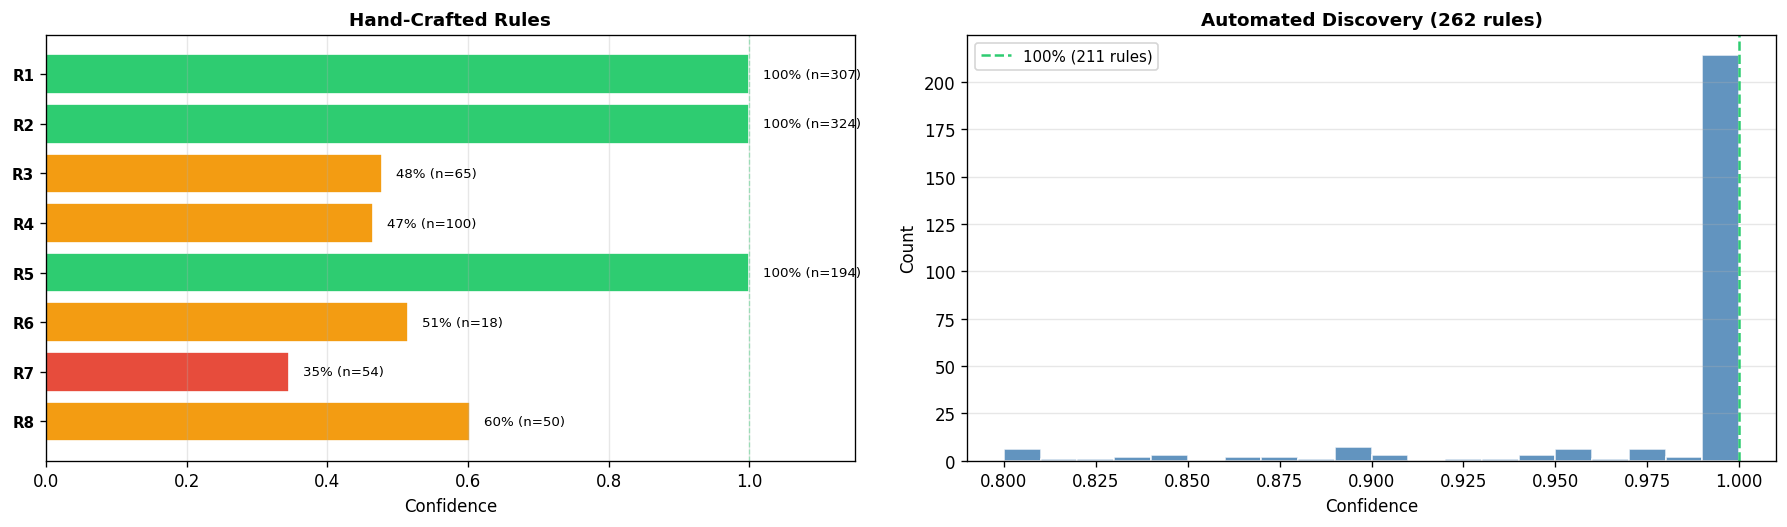

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Panel 1: Hand-crafted rule confidence
rule_labels = [r['description'].split(' · ')[1] if ' · ' in r['description']
               else r['description'] for r in all_rules]
confidences = [r['confidence'] for r in all_rules]
supports = [r['support'] for r in all_rules]
colors = ['#2ecc71' if c == 1.0 else '#f39c12' if c > 0.4 else '#e74c3c' for c in confidences]

axes[0].barh(range(len(all_rules)), confidences, color=colors, edgecolor='white')
axes[0].set_yticks(range(len(all_rules)))
axes[0].set_yticklabels([f"R{i+1}" for i in range(len(all_rules))], fontsize=9, weight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_xlim(0, 1.15)
axes[0].set_title('Hand-Crafted Rules', fontsize=11, weight='bold')
axes[0].axvline(1.0, color='#2ecc71', ls='--', lw=0.8, alpha=0.4)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
for i, (c, s) in enumerate(zip(confidences, supports)):
    axes[0].text(c + 0.02, i, f"{c:.0%} (n={s})", va='center', fontsize=8)

# Panel 2: Automated discovery histogram
auto_confs = [r['confidence'] for r in discovered_rules if not r['trivial']]
axes[1].hist(auto_confs, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(1.0, color='#2ecc71', ls='--', lw=1.5,
                label=f"100% ({sum(1 for c in auto_confs if c == 1.0)} rules)")
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Automated Discovery ({len(auto_confs)} rules)', fontsize=11, weight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/task3/rule_mining_overview.png', dpi=150, bbox_inches='tight')
plt.show()

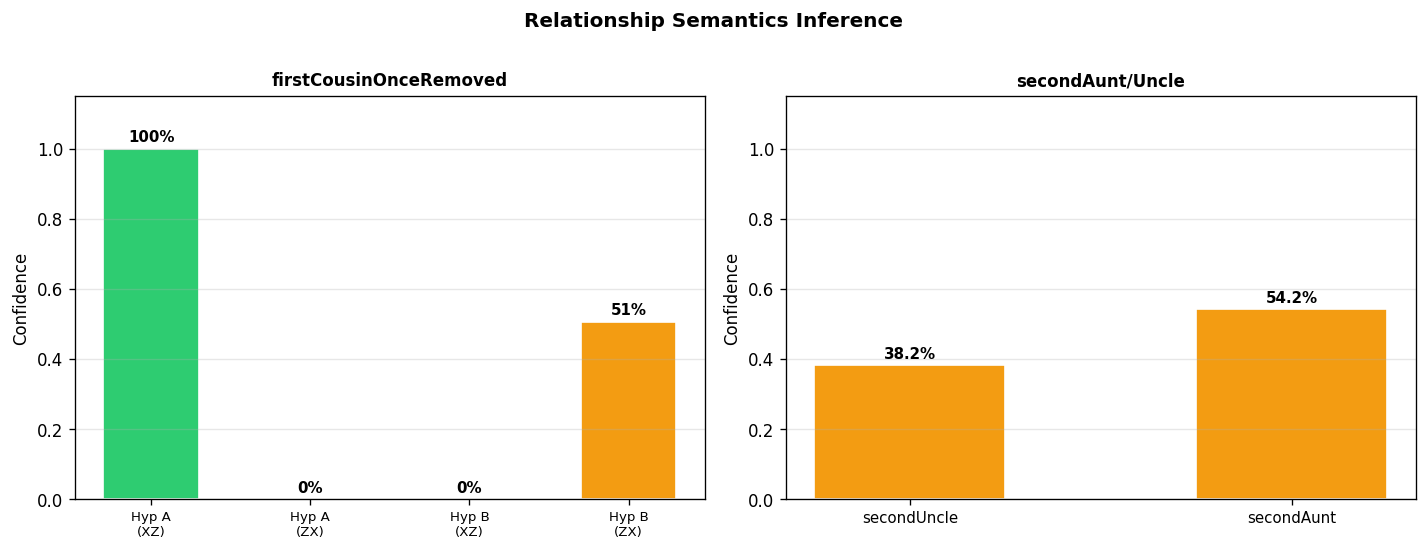

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: firstCousinOnceRemoved
labels_fc = ['Hyp A\n(XZ)', 'Hyp A\n(ZX)', 'Hyp B\n(XZ)', 'Hyp B\n(ZX)']
confs_fc = [hyp_a1_xz['confidence'], hyp_a1['confidence'],
            hyp_b1_xz['confidence'], hyp_b1['confidence']]
colors_fc = ['#2ecc71' if c == 1.0 else '#f39c12' if c > 0.3 else '#e74c3c' for c in confs_fc]
bars = axes[0].bar(range(4), confs_fc, color=colors_fc, edgecolor='white', width=0.6)
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(labels_fc, fontsize=8)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Confidence')
axes[0].set_title('firstCousinOnceRemoved', fontsize=10, weight='bold')
axes[0].grid(axis='y', alpha=0.3)
for bar, c in zip(bars, confs_fc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{c:.0%}', ha='center', fontsize=9, weight='bold')

# Panel 2: secondAunt/Uncle
labels_sa = ['secondUncle', 'secondAunt']
confs_sa = [sa_a1['confidence'], sa_a3['confidence']]
bars = axes[1].bar(range(2), confs_sa, color=['#f39c12']*2, edgecolor='white', width=0.5)
axes[1].set_xticks(range(2)); axes[1].set_xticklabels(labels_sa, fontsize=9)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel('Confidence')
axes[1].set_title('secondAunt/Uncle', fontsize=10, weight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, c in zip(bars, confs_sa):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{c:.1%}', ha='center', fontsize=9, weight='bold')

plt.suptitle('Relationship Semantics Inference', fontsize=12, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../images/task3/relationship_inference.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Regenerate the hand-crafted-rule findings table from `all_rules` ──────
# (2.2) The markdown table below this cell used to hard-code R1/R2 support
# counts from an earlier run of the code; they drifted out of sync with the
# actual output. Print it from `all_rules` instead so it can\'t drift again.
rule_insights = {
    1: "Gender pre-filtered by `sonOf`",
    2: "Sibling transitivity",
    3: "Gender-neutral body → ~50% split",
    4: "Same gender-split effect",
    5: "Deterministic 2-hop",
    6: "Parent's girl cousin",
    7: "`grandsonOf` includes grandmothers",
    8: "Better gender alignment",
}

print(f"{'#':<5}{'Rule':<52}{'Conf.':<8}{'Support':<9}{'Insight'}")
print("─" * 110)
for i, r in enumerate(all_rules, 1):
    conf_str = f"{r['confidence']:.1%}"
    print(f"R{i:<4}{r['rule']:<52}{conf_str:<8}{r['support']:<9}{rule_insights[i]}")

print(f"\nInverse rules:")
for i, r in enumerate(inverse_rules, 1):
    print(f"  INV{i}: {r['r1']}(X,Y) ⇒ {r['r2']}(Y,X)  conf={r['confidence']:.1%}  "
          f"(hits={r['hits']}/{r['body_count']})")

print(f"\nThree-hop chain rules:")
for i, r in enumerate(three_hop_rules, 1):
    print(f"  3H{i}: {r['rule_str']}  conf={r['confidence']:.1%}  "
          f"(support={r['support']}/{r['body_count']})")


#    Rule                                                Conf.   Support  Insight
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
R1   (X, sonOf, Y) ∧ (Y, motherOf, Z) ⇒ (X, brotherOf, Z)100.0%  307      Gender pre-filtered by `sonOf`
R2   (X, brotherOf, Y) ∧ (Y, sisterOf, Z) ⇒ (X, brotherOf, Z)100.0%  324      Sibling transitivity
R3   (X, nephewOf, Y) ∧ (Y, fatherOf, Z) ⇒ (Z, girlCousinOf, X)47.8%   65       Gender-neutral body → ~50% split
R4   (X, nieceOf, Y) ∧ (Y, motherOf, Z) ⇒ (Z, boyCousinOf, X)46.5%   100      Same gender-split effect
R5   (X, sonOf, Y) ∧ (Y, daughterOf, Z) ⇒ (Z, grandfatherOf/grandmotherOf, X)100.0%  194      Deterministic 2-hop
R6   (X, sonOf, Y) ∧ (Y, girlCousinOf, Z) ⇒ (Z, secondAuntOf, X)51.4%   18       Parent's girl cousin
R7   (X, grandsonOf, Y) ∧ (Y, brotherOf, Z) ⇒ (Z, greatUncleOf, X)34.6%   54       `grandsonOf` includes grandmothers
R8   (X, granddaughterOf, Y) ∧ (Y, sisterOf, Z) ⇒ (Z,

## 7. Key Findings

### R1–R8, the inverse rules, and the 3-hop chains
The table right above this cell is generated straight from `all_rules` / `inverse_rules` / `three_hop_rules`: I used to hand-type these numbers into a markdown table, and unsurprisingly they drifted out of sync with the actual code at some point. Printing it live fixes that permanently.

The pattern in that table, once you see it, explains basically everything: rules whose body already pins down a gender (R1's `sonOf` guarantees X is male, say) land at 100% confidence. Rules with a gender-neutral body (R3 and R4, where `fatherOf`/`motherOf` say nothing about the grandchild's gender) split roughly 50/50 across the two gendered relations they could imply, so no amount of data pushes them past a coin flip.

**What the semantics turned out to be:**
- `firstCousinOnceRemoved` is your parent's first cousin (100% confidence in the XZ direction), stored as (younger person, relation, older person).
- `secondAunt/Uncle` is also a parent's cousin: confidence sits around 54%, same gender-ambiguity story as above.

**Automated discovery** (§4) turned up a big pile of rules at ≥80% confidence and ≥10 support, and most of them hit 100%; see the counts printed there. That's a strong sign the graph is logically compositional rather than just being 13,821 unrelated facts.

**Rule types covered, for the record:** 2-hop Horn clauses (R1, R2, R5 all perfect), inverse/reciprocal rules (capped by the same gender issue), and 3-hop chains (great-uncle/aunt relationships, which need three relations strung together to express at all).
